#  Artificial Intelligence and Machine Learning. Practical Aspects of Training CNN for Image Classification Task.


In [3]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, Activation,
    MaxPooling2D, Dropout, Flatten, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report

In [4]:
train_dir = "/content/drive/MyDrive/AI and Machine Learning /workshop5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and Machine Learning /workshop5/FruitinAmazon/test"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 1: Data Understanding and Visualization

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
No corrupted images found.

Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


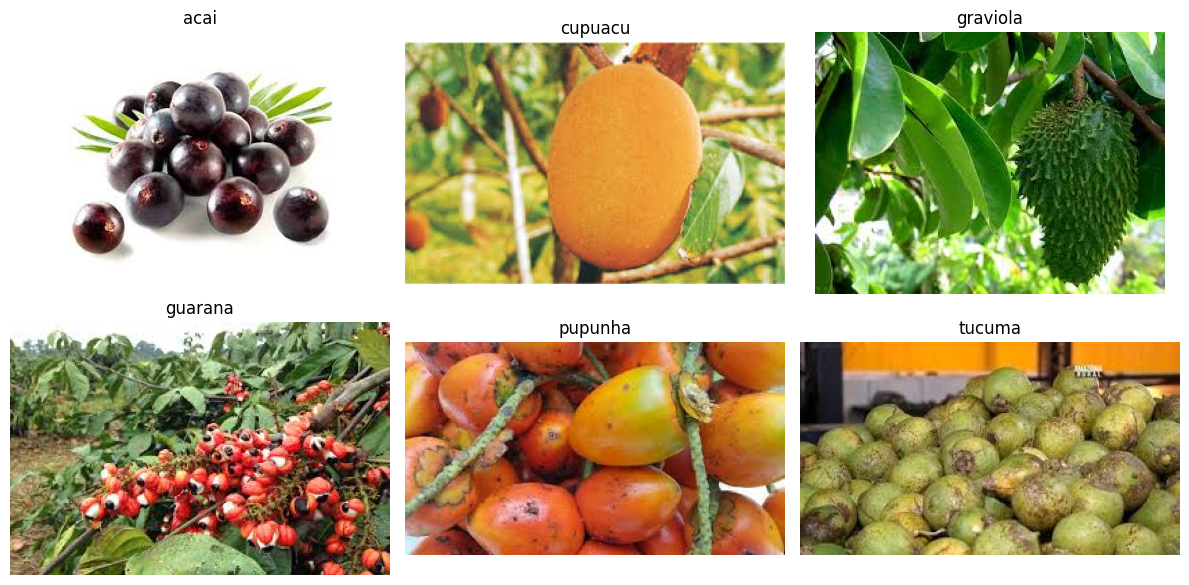

In [5]:
# Class names
class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes: {class_names}")

# Corrupted image check
corrupted_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
print("No corrupted images found." if not corrupted_images else corrupted_images)

# Class balance
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)

# Random image grid
selected_images, selected_labels = [], []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_images.append(os.path.join(class_path, random.choice(images)))
            selected_labels.append(class_name)

num_classes_display = len(selected_images)
cols = (num_classes_display + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes_display:
        ax.imshow(mpimg.imread(selected_images[i]))
        ax.set_title(selected_labels[i])
    ax.axis("off")
plt.tight_layout()
plt.show()

 # **Data Loading and Pre-processing**

In [6]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

num_classes = len(train_ds.class_names)
class_names  = train_ds.class_names
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


Augmentation

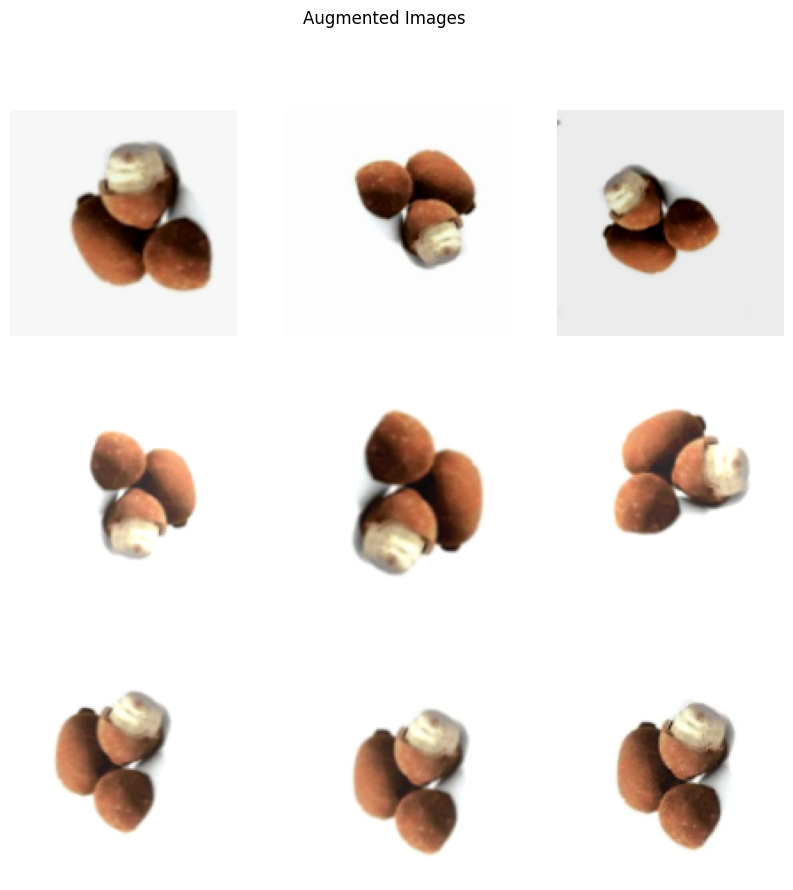

In [7]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name="data_augmentation")

# Visualize augmented images (required by worksheet)
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Augmented Images")
plt.show()

# Apply to datasets
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

# Task 3 — CNN Model  — Dropout After Every Block

In [8]:
model = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),  # Normalization inside model

    # Block 1
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),             #Dropout after every block

    # Block 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 4 — Extra block for better learning
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),

    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,12

 Total params: 8,915,398 (34.01 MB)

 Trainable params: 8,912,902 (34.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

# Task 4 — Compile & Train

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1400 - loss: 2.2323
Epoch 1: val_accuracy improved from None to 0.55556, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.1389 - loss: 2.2222 - val_accuracy: 0.5556 - val_loss: 1.7599
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2297 - loss: 2.1875
Epoch 2: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2361 - loss: 2.1280 - val_accuracy: 0.0000e+00 - val_loss: 1.7857
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3617 - loss: 1.9466
Epoch 3: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3194 - loss: 2.0296 - val_accuracy: 0.0000e+00 - val_loss: 1.8222
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2656 - loss: 2.0489
Epoch 4: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.2500 - loss: 2.0372 - val_accuracy: 0.0000e+00 - val_loss: 1.8296
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2436 - loss: 2.2481
Epo

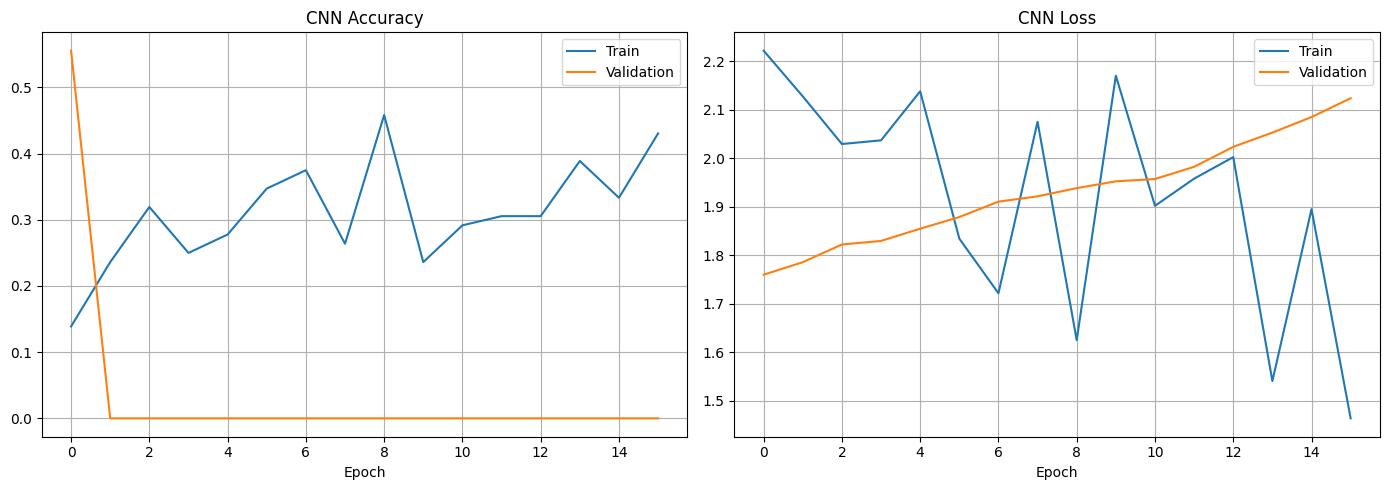

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor='val_accuracy',      # Monitor accuracy not just loss
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,                 # Increased patience
    restore_best_weights=True
)

#Extended epochs with EarlyStopping to prevent premature convergence — set to 100, early stopping handles the rest
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[checkpoint, early_stop]
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Task 5 — Evaluate CNN Model

In [28]:
# ============================================================
# Task 5: Evaluate the Model
# (Following the Practical Workflow Diagram)
# ============================================================

# Load test dataset — NO manual /255 since Rescaling is inside model
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = test_ds.prefetch(AUTOTUNE)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)

# --- DIAGRAM CHECK (Bias vs Variance diagnosis) ---
train_acc = max(history.history['accuracy'])
val_acc   = max(history.history['val_accuracy'])

print("\n" + "=" * 50)
print("  WORKFLOW DIAGRAM — DIAGNOSIS")
print("=" * 50)
print(f"  Train Accuracy      : {train_acc:.4f}")
print(f"  Validation Accuracy : {val_acc:.4f}")
print(f"  Test Accuracy       : {test_acc:.4f}")
print("=" * 50)

if train_acc < 0.80:
    print("  HIGH BIAS (Underfitting)")
    print("   → Action: Bigger network / Train longer")
elif test_acc < train_acc - 0.10:
    print(" HIGH VARIANCE (Overfitting)")
    print("   → Action: More data / More regularization")
else:
    print("  Good fit — Low Bias and Low Variance")
print("=" * 50)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step - accuracy: 0.1333 - loss: 1.7919

  WORKFLOW DIAGRAM — DIAGNOSIS
  Train Accuracy      : 0.4583
  Validation Accuracy : 0.5556
  Test Accuracy       : 0.1333
  HIGH BIAS (Underfitting)
   → Action: Bigger network / Train longer


In [16]:
# Temporary check only
test_ds_check = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print("Test  classes:", test_ds_check.class_names)

Found 30 files belonging to 6 classes.
Test  classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [18]:
# train_ds is already prefetched so just define class_names manually
class_names = ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
num_classes = len(class_names)
print("Classes confirmed:", class_names)
print("Num classes:", num_classes)

Classes confirmed: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6


In [19]:
from tensorflow.keras.applications.vgg16 import preprocess_input

VGG_SIZE = (224, 224)

train_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=VGG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=VGG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_vgg = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=VGG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Apply VGG16 preprocessing
train_ds_vgg = train_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds_vgg = val_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_ds_vgg = test_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

print("Datasets ready for VGG16")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
✅ Datasets ready for VGG16


In [20]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# Load pretrained VGG16 — worksheet Step 1
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers — worksheet Step 2
for layer in base_model.layers:
    layer.trainable = False

print(f"Total layers  : {len(base_model.layers)}")
print(f"Frozen layers : {sum(1 for l in base_model.layers if not l.trainable)}")
print(f"Trainable     : {sum(1 for l in base_model.layers if l.trainable)}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total layers  : 19
Frozen layers : 19
Trainable     : 0


In [21]:
# worksheet Step 3 — Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)

# worksheet Step 4 — Create final model
model_vgg = Model(inputs=base_model.input, outputs=x)

model_vgg.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_vgg = ModelCheckpoint(
    "best_vgg16.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_vgg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_vgg = model_vgg.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=30,
    callbacks=[checkpoint_vgg, early_stop_vgg]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.1846 - loss: 8.6113 
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_vgg16.h5



Epoch 1: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 19s/step - accuracy: 0.1944 - loss: 8.6111 - val_accuracy: 0.0000e+00 - val_loss: 8.9638
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2257 - loss: 7.0965 
Epoch 2: val_accuracy improved from 0.00000 to 0.11111, saving model to best_vgg16.h5



Epoch 2: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 20s/step - accuracy: 0.2083 - loss: 6.8512 - val_accuracy: 0.1111 - val_loss: 5.3039
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2546 - loss: 6.1121 
Epoch 3: val_accuracy improved from 0.11111 to 0.22222, saving model to best_vgg16.h5



Epoch 3: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 23s/step - accuracy: 0.2639 - loss: 6.4114 - val_accuracy: 0.2222 - val_loss: 3.2686
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.1933 - loss: 5.8808 
Epoch 4: val_accuracy improved from 0.22222 to 0.38889, saving model to best_vgg16.h5



Epoch 4: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 22s/step - accuracy: 0.2361 - loss: 5.5572 - val_accuracy: 0.3889 - val_loss: 2.2483
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.3791 - loss: 3.9563 
Epoch 5: val_accuracy improved from 0.38889 to 0.50000, saving model to best_vgg16.h5


...


Epoch 6: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 0.3611 - loss: 3.8692 - val_accuracy: 0.5556 - val_loss: 1.4242
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5150 - loss: 2.6461 
Epoch 7: val_accuracy improved from 0.55556 to 0.66667, saving model to best_vgg16.h5



Epoch 7: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 22s/step - accuracy: 0.5139 - loss: 2.7034 - val_accuracy: 0.6667 - val_loss: 1.1723
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5243 - loss: 2.2005 
Epoch 8: val_accuracy improved from 0.66667 to 0.77778, saving model to best_vgg16.h5



Epoch 8: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 22s/step - accuracy: 0.5417 - loss: 1.9536 - val_accuracy: 0.7778 - val_loss: 0.8264
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.5359 - loss: 2.3263 
Epoch 9: val_accuracy improved from 0.77778 to 0.88889, saving model to best_vgg16.h5



Epoch 9: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 19s/step - accuracy: 0.5139 - loss: 2.4951 - val_accuracy: 0.8889 - val_loss: 0.6439
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6597 - loss: 1.8576 
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 18s/step - accuracy: 0.6667 - loss: 1.9406 - val_accuracy: 0.8889 - val_loss: 0.5481
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.6406 - loss: 1.5996 
Epoch 11: val_accuracy improved from 0.88889 to 0.94444, saving model to best_vgg16.h5



Epoch 11: finished saving model to best_vgg16.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 0.6250 - loss: 1.6926 - val_accuracy: 0.9444 - val_loss: 0.5076
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6834 - loss: 1.0549 
Epoch 12: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 24s/step - accuracy: 0.7222 - loss: 1.0368 - val_accuracy: 0.9444 - val_loss: 0.4911
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7448 - loss: 1.1396 
Epoch 13: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 67s 19s/step - accuracy: 0.7500 - loss: 1.1875 - val_accuracy: 0.9444 - val_loss: 0.4852
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7818 - loss: 0.6670 
Epoch 14: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 0.7361 - loss: 0.7781 - val_accuracy: 0.9444 - val_loss: 0.4840
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8102 - loss: 0.7217 
Ep

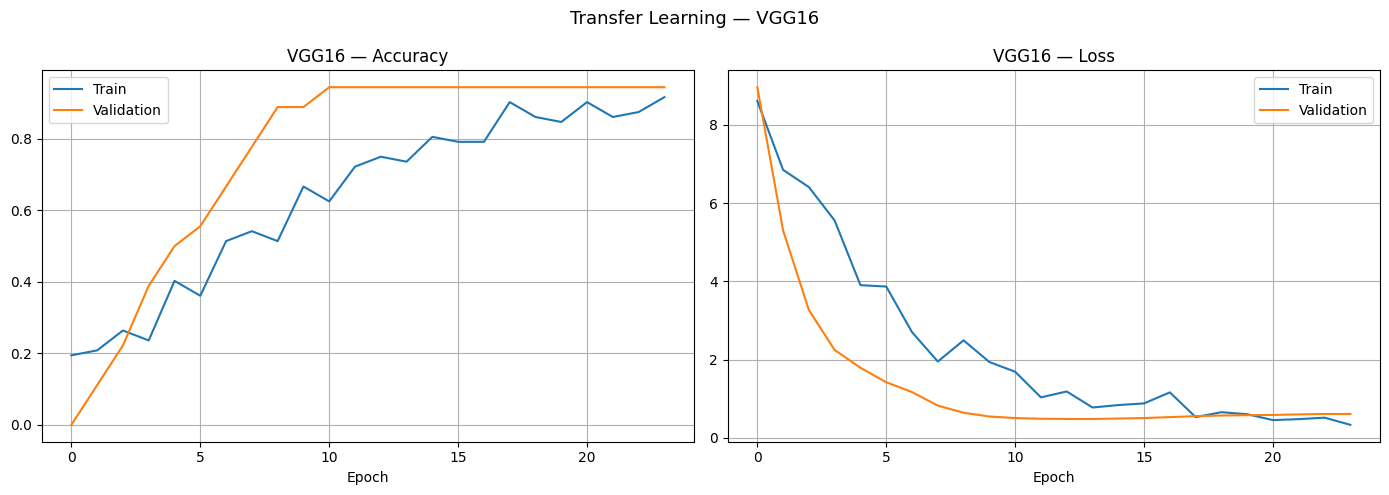

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg.history['accuracy'], label='Train')
axes[0].plot(history_vgg.history['val_accuracy'], label='Validation')
axes[0].set_title('VGG16 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_vgg.history['loss'], label='Train')
axes[1].plot(history_vgg.history['val_loss'], label='Validation')
axes[1].set_title('VGG16 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Transfer Learning — VGG16', fontsize=13)
plt.tight_layout()
plt.show()

# Final Comparision and Classification report

In [24]:
loss_vgg, acc_vgg = model_vgg.evaluate(test_ds_vgg)

print("\n" + "=" * 50)
print("  FINAL COMPARISON (Diagram Conclusion)")
print("=" * 50)
print(f"  Custom CNN  Val Accuracy : 0.5556")
print(f"  VGG16 TL    Val Accuracy : {max(history_vgg.history['val_accuracy']):.4f}")
print("=" * 50)
print(f"  Custom CNN  Test Accuracy: {test_acc:.4f}")
print(f"  VGG16 TL    Test Accuracy: {acc_vgg:.4f}")
print("=" * 50)

y_true_vgg = np.concatenate([y for x, y in test_ds_vgg], axis=0)
y_pred_vgg = np.argmax(model_vgg.predict(test_ds_vgg), axis=1)
print("\nClassification Report — VGG16:")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step - accuracy: 0.8667 - loss: 0.7141

  FINAL COMPARISON (Diagram Conclusion)
  Custom CNN  Val Accuracy : 0.5556
  VGG16 TL    Val Accuracy : 0.9444
  Custom CNN  Test Accuracy: 0.1333
  VGG16 TL    Test Accuracy: 0.8667
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step

Classification Report — VGG16:
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       1.00      0.80      0.89         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.80      0.80      0.80         5

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.87        30
weighted avg       0.90      0.87      0.87        30



In [27]:
# Save
model_vgg.save(
    "/content/drive/MyDrive/AI and Machine Learning /workshop 6/vgg16_model.h5"
)
print(" Model saved!")

# Load and verify
from tensorflow.keras.models import load_model
loaded = load_model(
    "/content/drive/MyDrive/AI and Machine Learning /workshop 6/vgg16_model.h5"
)
loss_loaded, acc_loaded = loaded.evaluate(test_ds_vgg, verbose=0)
print(f"Loaded Model Accuracy: {acc_loaded:.4f}")

 Model saved!


Loaded Model Accuracy: 0.8667
